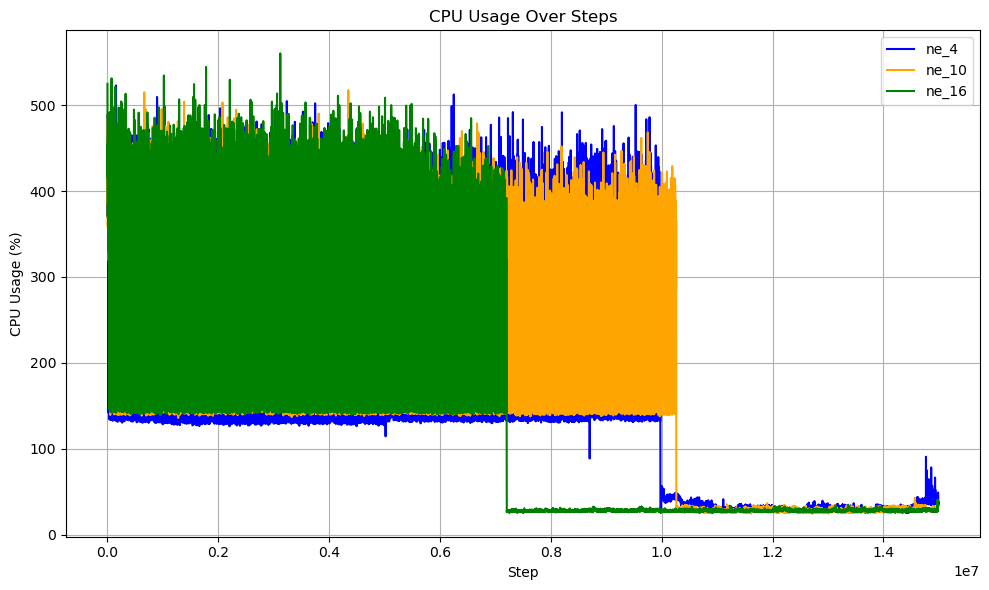

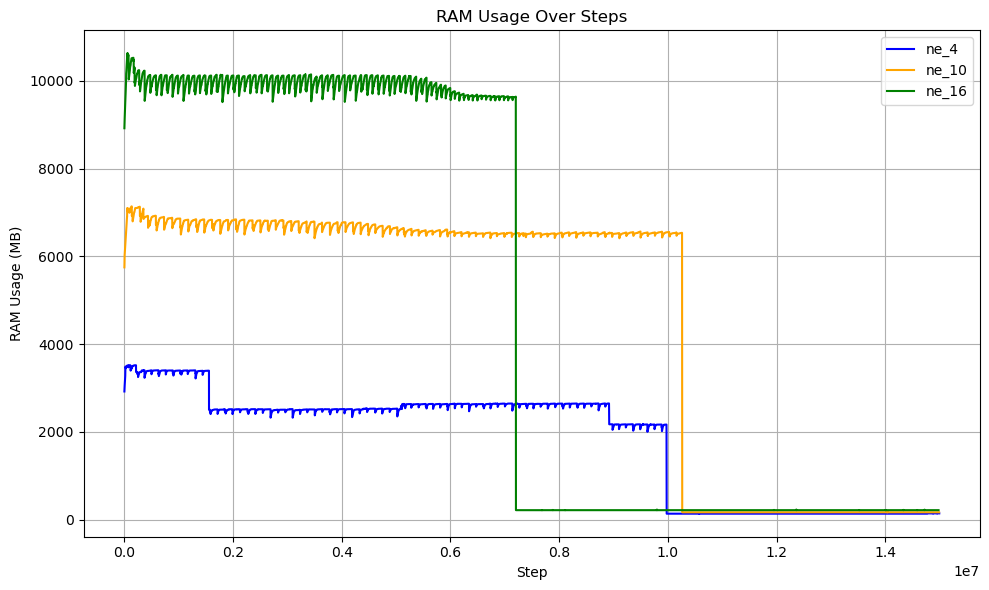

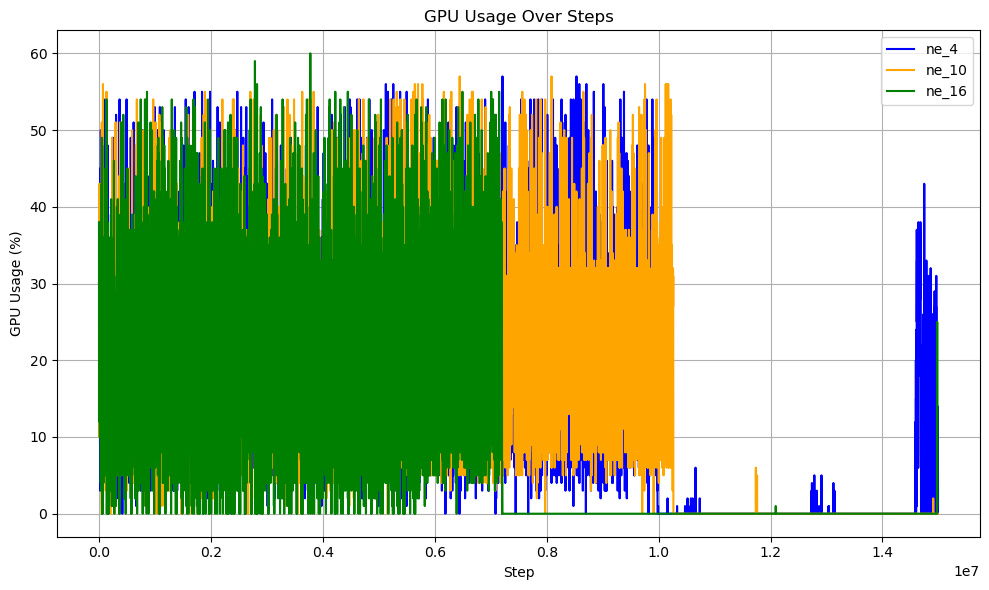

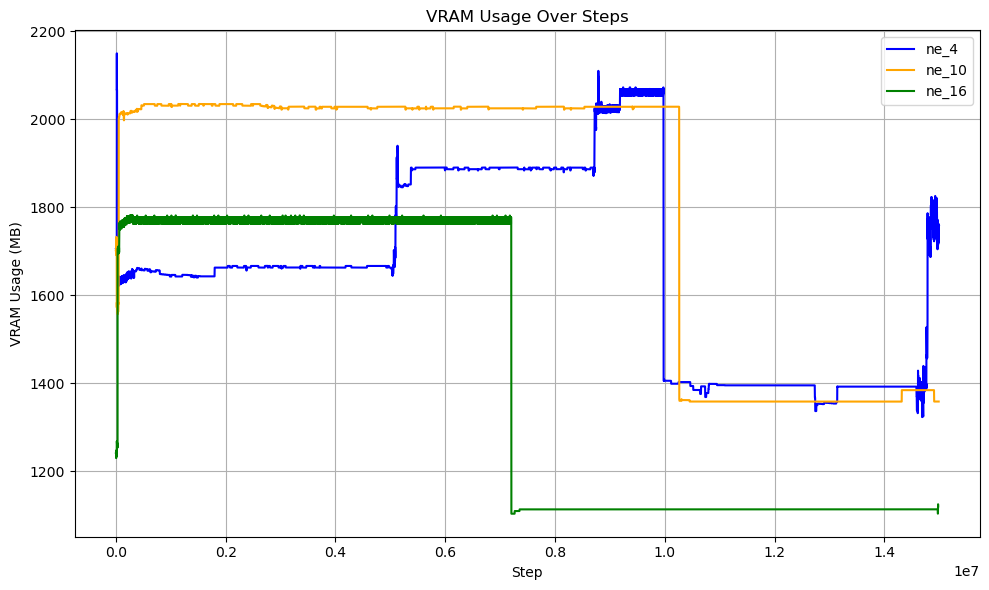

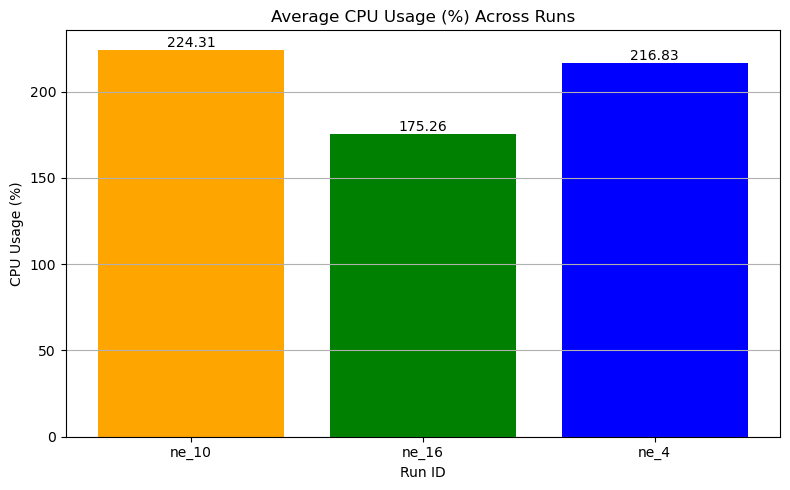

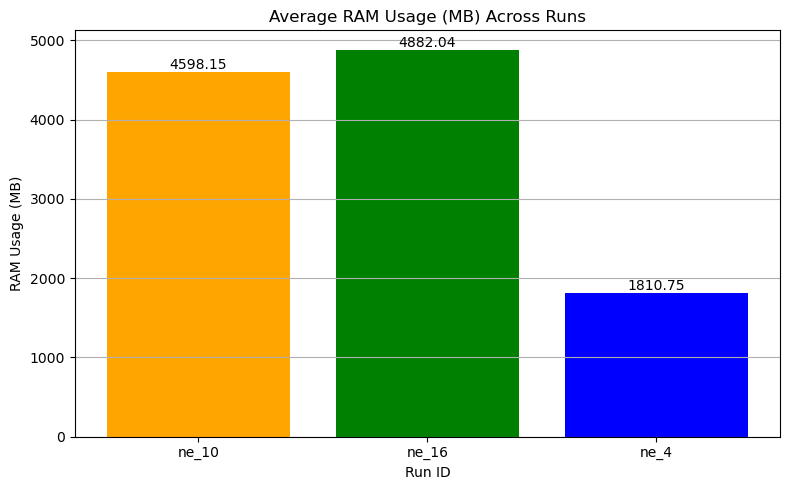

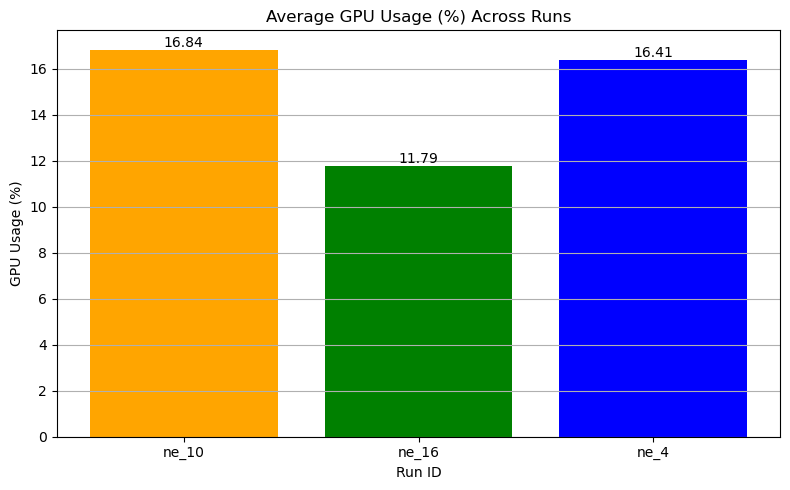

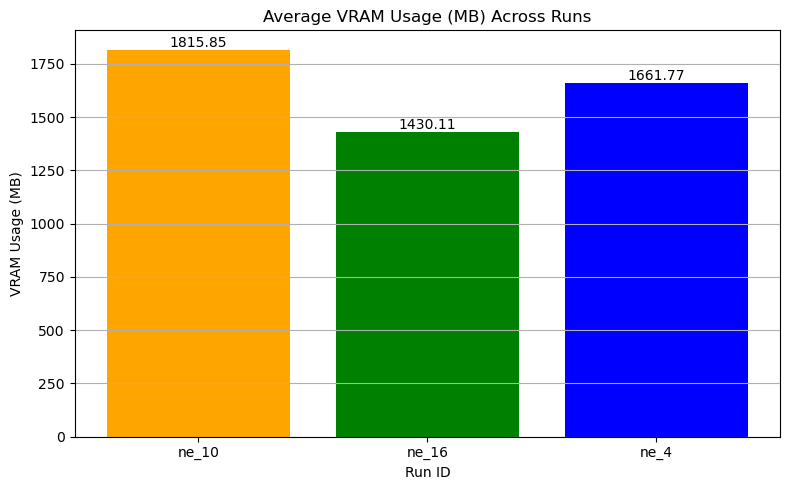

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths for the CSV files
# file_paths = [
#     "results/base/resource_metrics.csv",
#     "results/bs_bs_4096_40960/resource_metrics.csv",
#     "results/bs_bs_8192_81920/resource_metrics.csv"
# ]

# run_ids = [
#     "batch/buffer size: 2048/20480",
#     "batch/buffer size: 4096/40960",
#     "batch/buffer size: 8192/81920"
# ]

file_paths = [
    "results/ne_4/resource_metrics.csv",
    "results/ne_10/resource_metrics.csv",
    "results/ne_16/resource_metrics.csv",
]

run_ids = [
    "ne_4",
    "ne_10",
    "ne_16",
]

# Load and process data
# Change max_step to the number of steps of the runs
def load_data(file_paths, run_ids, max_step=15000000):
    dataframes = []
    for idx, file_path in enumerate(file_paths):
        df = pd.read_csv(file_path)
        df['Run ID'] = run_ids[idx]  # Map Run IDs to the provided run_ids array
        num_rows = len(df)
        step_values = pd.Series(range(0, max_step + 1, max_step // num_rows)).iloc[:num_rows]
        df['Step'] = step_values
        df = df.drop(columns=['Timestamp'])  # Remove the Timestamp column
        dataframes.append(df)
    return pd.concat(dataframes, ignore_index=True)

data = load_data(file_paths, run_ids)

# Define a consistent color mapping for each Run ID
run_id_colors = {
    run_id: color
    for run_id, color in zip(data['Run ID'].unique(), ['blue', 'orange', 'green'])
}

# Plotting function for line charts
def plot_metrics(data, metric, ylabel, title):
    plt.figure(figsize=(10, 6))
    for run_id in data['Run ID'].unique():
        run_data = data[data['Run ID'] == run_id]
        plt.plot(run_data['Step'], run_data[metric], label=run_id, color=run_id_colors[run_id])

    plt.xlabel("Step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Visualize metrics over steps
plot_metrics(data, 'CPU Usage (%)', 'CPU Usage (%)', 'CPU Usage Over Steps')
plot_metrics(data, 'RAM Usage (MB)', 'RAM Usage (MB)', 'RAM Usage Over Steps')
plot_metrics(data, 'GPU Usage (%)', 'GPU Usage (%)', 'GPU Usage Over Steps')
plot_metrics(data, 'VRAM Usage (MB)', 'VRAM Usage (MB)', 'VRAM Usage Over Steps')

# Compute averages for bar chart
average_metrics = data.groupby('Run ID').mean().reset_index()
print(average_metrics.head())

# Plotting function for bar charts with values displayed
def plot_individual_bar_chart(average_metrics, metric, ylabel, title):
    plt.figure(figsize=(8, 5))
    colors = [run_id_colors[run_id] for run_id in average_metrics['Run ID']]
    bars = plt.bar(average_metrics['Run ID'], average_metrics[metric], color=colors)
    
    # Add text annotations on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', 
                 ha='center', va='bottom', fontsize=10)
    
    plt.xlabel("Run ID")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Metrics to compare
metrics_to_plot = {
    'CPU Usage (%)': 'CPU Usage (%)',
    'RAM Usage (MB)': 'RAM Usage (MB)',
    'GPU Usage (%)': 'GPU Usage (%)',
    'VRAM Usage (MB)': 'VRAM Usage (MB)',
}

# Generate individual bar charts for each metric
for metric, ylabel in metrics_to_plot.items():
    plot_individual_bar_chart(average_metrics, metric, ylabel, f'Average {ylabel} Across Runs')
